## 4.1
Implement classification on the standard dataset iris, using k-means clustering, in two versions:
- clustering on the whole dataset with classification by majority of the centroids,
- clustering separately of each class.
Compare test error in both cases for the same total number of clusters, analysing in particular the error for different values of the clusters number.

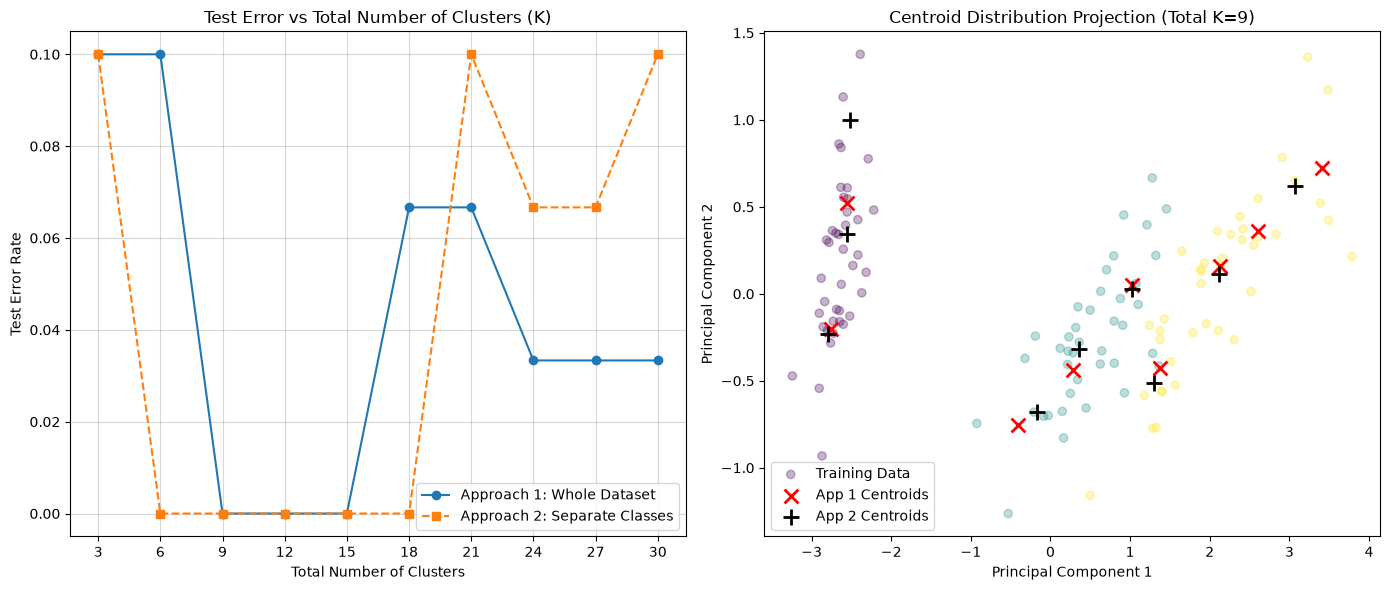

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.decomposition import PCA
import warnings

# Suppress minor memory warnings from KMeans
warnings.filterwarnings('ignore')

# 1. Load and prepare the standard Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Use stratify=y to ensure proportional class representation in train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Setup the cluster evaluations
# Since there are 3 classes, we increment total clusters in multiples of 3
# so they can be distributed equally (k per class) in Approach 2.
k_per_class_values = range(1, 11)
total_clusters_list = [k * 3 for k in k_per_class_values]

errors_app1 = []
errors_app2 = []

for k_per_class in k_per_class_values:
    K_total = k_per_class * 3
    
    # ==========================================
    # Approach 1: Clustering on the whole dataset
    # ==========================================
    km1 = KMeans(n_clusters=K_total, random_state=42, n_init=10)
    km1.fit(X_train)
    
    # Assign class to each centroid by majority vote of training points in that cluster
    centroid_labels1 = np.zeros(K_total, dtype=int)
    for i in range(K_total):
        idx = np.where(km1.labels_ == i)[0]
        if len(idx) > 0:
            centroid_labels1[i] = np.bincount(y_train[idx]).argmax()
        else:
            centroid_labels1[i] = -1 # Handle empty cluster case
            
    # Classify test points by finding the nearest centroid
    closest1, _ = pairwise_distances_argmin_min(X_test, km1.cluster_centers_)
    y_pred1 = centroid_labels1[closest1]
    errors_app1.append(np.mean(y_pred1 != y_test))
    
    # ==========================================
    # Approach 2: Clustering separately by class
    # ==========================================
    centroids2 = []
    labels2 = []
    
    for c in range(3):
        # Isolate training data for class c
        X_c = X_train[y_train == c]
        
        # Fit KMeans only on data of class c
        km2 = KMeans(n_clusters=k_per_class, random_state=42, n_init=10)
        km2.fit(X_c)
        
        centroids2.append(km2.cluster_centers_)
        labels2.extend([c] * k_per_class)
        
    centroids2 = np.vstack(centroids2)
    labels2 = np.array(labels2)
    
    # Classify test points by finding the nearest centroid among all classes
    closest2, _ = pairwise_distances_argmin_min(X_test, centroids2)
    y_pred2 = labels2[closest2]
    errors_app2.append(np.mean(y_pred2 != y_test))

# ==========================================
# 3. Plotting and Analysis
# ==========================================
plt.figure(figsize=(14, 6))

# Plot 1: Test Error Comparison
plt.subplot(1, 2, 1)
plt.plot(total_clusters_list, errors_app1, marker='o', linestyle='-', label='Approach 1: Whole Dataset')
plt.plot(total_clusters_list, errors_app2, marker='s', linestyle='--', label='Approach 2: Separate Classes')
plt.title('Test Error vs Total Number of Clusters (K)')
plt.xlabel('Total Number of Clusters')
plt.ylabel('Test Error Rate')
plt.xticks(total_clusters_list)
plt.grid(True, alpha=0.5)
plt.legend()

# Plot 2: Explanatory PCA Visualization for K=9
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

plt.subplot(1, 2, 2)
# Plot training data
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', 
                      alpha=0.3, label='Training Data')

# Re-run specifically for K=9 (k=3 per class) to visualize centroid placement
k_vis = 3
K_total_vis = k_vis * 3

# App 1 Centroids
km1_vis = KMeans(n_clusters=K_total_vis, random_state=42, n_init=10).fit(X_train)
centroids1_pca = pca.transform(km1_vis.cluster_centers_)
plt.scatter(centroids1_pca[:, 0], centroids1_pca[:, 1], c='red', marker='x', 
            s=100, linewidth=2, label='App 1 Centroids')

# App 2 Centroids
centroids2_pca_list = []
for c in range(3):
    X_c = X_train[y_train == c]
    km2_vis = KMeans(n_clusters=k_vis, random_state=42, n_init=10).fit(X_c)
    centroids2_pca_list.append(pca.transform(km2_vis.cluster_centers_))
centroids2_pca = np.vstack(centroids2_pca_list)
plt.scatter(centroids2_pca[:, 0], centroids2_pca[:, 1], c='black', marker='+', 
            s=120, linewidth=2, label='App 2 Centroids')

plt.title(f'Centroid Distribution Projection (Total K={K_total_vis})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.tight_layout()
plt.show()

Averaged over 30 stratified splits (test size 20%)

 K_total         Approach 1         Approach 2
       3     0.1133 +/- 0.0409     0.0800 +/- 0.0491
       6     0.1011 +/- 0.0339     0.0422 +/- 0.0354
       9     0.0189 +/- 0.0205     0.0189 +/- 0.0222
      12     0.0311 +/- 0.0354     0.0267 +/- 0.0249
      15     0.0322 +/- 0.0279     0.0289 +/- 0.0254
      18     0.0378 +/- 0.0362     0.0422 +/- 0.0333
      21     0.0333 +/- 0.0310     0.0378 +/- 0.0352
      24     0.0389 +/- 0.0395     0.0478 +/- 0.0362
      27     0.0433 +/- 0.0386     0.0489 +/- 0.0307
      30     0.0389 +/- 0.0414     0.0422 +/- 0.0333

Best K (Approach 1): 9  error = 0.0189
Best K (Approach 2): 9  error = 0.0189


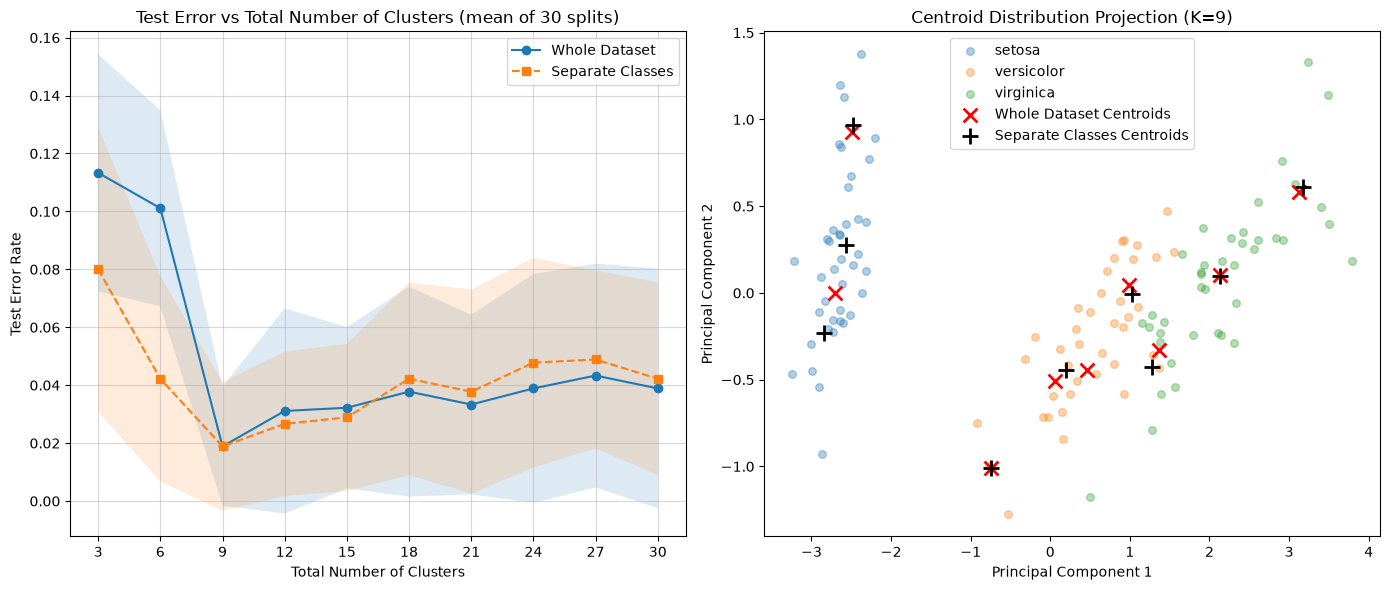

In [5]:
# 4.1 — corrected version
#
# Two fixes over the cell above:
#  1. The test error was estimated on a single split with 30 test points, so it was
#     quantised to 1/30 = 0.033 and the two curves differed by one or two points at
#     most. Here the whole experiment is repeated over N_REPEATS stratified splits
#     (and a different KMeans seed each time), reporting mean +/- std.
#  2. Empty clusters in Approach 1 were labelled -1, which silently counts as an
#     error for every test point routed to them. Empty centroids are now removed
#     from the candidate set instead, so no test point can be assigned to one.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.decomposition import PCA
import warnings

# Scoped to the known KMeans/MKL message rather than silencing every warning
warnings.filterwarnings('ignore', message='KMeans is known to have a memory leak')

# 1. Load and prepare the standard Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
n_classes = len(np.unique(y))

# 2. Setup the cluster evaluations
# Total clusters increment in multiples of n_classes so they can be distributed
# equally (k per class) in Approach 2.
k_per_class_values = range(1, 11)
total_clusters_list = [k * n_classes for k in k_per_class_values]
N_REPEATS = 30
TEST_SIZE = 0.2


def fit_approach1(X_train, y_train, K_total, seed):
    """Cluster the whole training set, label each centroid by majority vote."""
    km = KMeans(n_clusters=K_total, random_state=seed, n_init=10).fit(X_train)

    # Keep only non-empty clusters: an empty centroid has no majority class and
    # must not be a classification candidate.
    non_empty = [i for i in range(K_total) if np.any(km.labels_ == i)]
    centroids = km.cluster_centers_[non_empty]
    labels = np.array([np.bincount(y_train[km.labels_ == i]).argmax() for i in non_empty])
    return centroids, labels


def fit_approach2(X_train, y_train, k_per_class, seed):
    """Cluster each class separately; every centroid inherits its class label."""
    centroids, labels = [], []
    for c in range(n_classes):
        X_c = X_train[y_train == c]
        # Guard against asking for more clusters than the class has points
        k_c = min(k_per_class, len(X_c))
        km = KMeans(n_clusters=k_c, random_state=seed, n_init=10).fit(X_c)
        centroids.append(km.cluster_centers_)
        labels.extend([c] * k_c)
    return np.vstack(centroids), np.array(labels)


def test_error(centroids, labels, X_test, y_test):
    """Classify test points by nearest centroid and return the error rate."""
    closest, _ = pairwise_distances_argmin_min(X_test, centroids)
    return np.mean(labels[closest] != y_test)


# 3. Repeated evaluation: shape (n_k_values, N_REPEATS)
errors_app1 = np.zeros((len(k_per_class_values), N_REPEATS))
errors_app2 = np.zeros((len(k_per_class_values), N_REPEATS))

for r in range(N_REPEATS):
    # A different stratified split and a different KMeans seed on every repeat
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=r, stratify=y
    )
    for i, k_per_class in enumerate(k_per_class_values):
        K_total = k_per_class * n_classes

        c1, l1 = fit_approach1(X_train, y_train, K_total, seed=r)
        errors_app1[i, r] = test_error(c1, l1, X_test, y_test)

        c2, l2 = fit_approach2(X_train, y_train, k_per_class, seed=r)
        errors_app2[i, r] = test_error(c2, l2, X_test, y_test)

mean1, std1 = errors_app1.mean(axis=1), errors_app1.std(axis=1)
mean2, std2 = errors_app2.mean(axis=1), errors_app2.std(axis=1)

print(f"Averaged over {N_REPEATS} stratified splits (test size {TEST_SIZE:.0%})\n")
print(f"{'K_total':>8} {'Approach 1':>18} {'Approach 2':>18}")
for i, K_total in enumerate(total_clusters_list):
    print(f"{K_total:>8} {mean1[i]:>10.4f} +/- {std1[i]:.4f} {mean2[i]:>10.4f} +/- {std2[i]:.4f}")

print(f"\nBest K (Approach 1): {total_clusters_list[np.argmin(mean1)]}  "
      f"error = {mean1.min():.4f}")
print(f"Best K (Approach 2): {total_clusters_list[np.argmin(mean2)]}  "
      f"error = {mean2.min():.4f}")

# ==========================================
# 4. Plotting and Analysis
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Test Error Comparison, with +/- 1 std bands across repeats
axes[0].plot(total_clusters_list, mean1, marker='o', linestyle='-', label='Whole Dataset')
axes[0].fill_between(total_clusters_list, mean1 - std1, mean1 + std1, alpha=0.15)
axes[0].plot(total_clusters_list, mean2, marker='s', linestyle='--', label='Separate Classes')
axes[0].fill_between(total_clusters_list, mean2 - std2, mean2 + std2, alpha=0.15)
axes[0].set_title(f'Test Error vs Total Number of Clusters (mean of {N_REPEATS} splits)')
axes[0].set_xlabel('Total Number of Clusters')
axes[0].set_ylabel('Test Error Rate')
axes[0].set_xticks(total_clusters_list)
axes[0].grid(True, alpha=0.5)
axes[0].legend()

# Plot 2: Explanatory PCA visualisation on one representative split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=0, stratify=y
)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

k_vis = 3
K_total_vis = k_vis * n_classes

# One scatter per class so the legend actually names what is plotted
for c, name in enumerate(iris.target_names):
    m = y_train == c
    axes[1].scatter(X_train_pca[m, 0], X_train_pca[m, 1], alpha=0.35, s=30, label=name)

c1_vis, _ = fit_approach1(X_train, y_train, K_total_vis, seed=0)
c1_pca = pca.transform(c1_vis)
axes[1].scatter(c1_pca[:, 0], c1_pca[:, 1], c='red', marker='x',
                s=100, linewidth=2, label='Whole Dataset Centroids')

c2_vis, _ = fit_approach2(X_train, y_train, k_vis, seed=0)
c2_pca = pca.transform(c2_vis)
axes[1].scatter(c2_pca[:, 0], c2_pca[:, 1], c='black', marker='+',
                s=120, linewidth=2, label='Separate Classes Centroids')

axes[1].set_title(f'Centroid Distribution Projection (K={K_total_vis})')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend()

plt.tight_layout()
plt.show()